In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [5]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/gsv3", token=api_key)

Loaded as API: https://verdantintel-gsv3.hf.space


# Helper Function

In [12]:
def parse_events(text):

    events = []

    for block in text.strip().split("\n\n"):
        lines = block.split("\n")

        event = {"title": lines[0].strip()}

        for line in lines[1:]:
            if ":" in line:
                key, value = line.split(":", 1)
                key = key.strip().lower().replace(" ", "_")
                value = value.strip()
                event[key] = value

        events.append(event)

    return events

In [13]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    #answer = ast.literal_eval(answer)
    events = parse_events(answer)

    return events

    #return answer

# Searching for Data

In [56]:
question = 'what events happen in hillsboro, beaverton, or portland in 2026?'

answer = ask_api(client, question)
event_df = pd.DataFrame(answer)
event_df.head()

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url
0,Conexión Latina,Not provided in source.,"March 27, 2026 5:30 PM - 8:00 PM",Not provided in source.,Not provided in source.,Not provided in source.,Name: Christian Arroyo,,,
1,GHOST IN THE CLOVER with guests,Not provided in source.,"March 13, 2026 at 07:00 pm PDT",$14.94,Dante's Live,"350 W Burnside St, Portland, OR, 97209, US","(866) 777-8932, DantesStarTheater@gmail.com",Ghost In The Clover will perform at Dante's Li...,Not provided in source.,https://www.danteslive.com/tm-event/ghost-in-t...
2,River Roads - Portland,Virtuoso pianists from the University of Orego...,"Sunday, February 1, 2026 7:00 PM",Not provided in source.,"Lincoln Hall, Room 75","Portland, Oregon",info@cascadiacomposers.org,River Roads is part of the Oregon Soundscapes ...,Modern Classical,https://www.cascadiacomposers.org/upcoming
3,TWI-HARD: Twilight Saga Triple Feature,Not provided in source.,"January 3, 2026 2:00 pm - 8:30 pm","$24.50 Adults, $22.50 Seniors 65+, $27.50 Memb...",PAM CUT’s Tomorrow Theater,"3530 SE Division St., Portland, OR 97202",Email: tomorrow@pamcut.org,Description:,Genres:,Source URL:
4,Hope is Beyond Words Opening Reception & First...,Not provided in source.,"April 03, 2026 6:00pm",FREE,The Reser,"12625 SW Crescent St, Beaverton, OR 97005",Not provided in source.,Join The Reser for the opening reception of “H...,Not provided in source.,https://thereser.org/event/hope-is-beyond-word...


In [57]:
event_df.shape

(997, 10)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [58]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [59]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [60]:
event_df.head()

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url
0,Conexión Latina,Not provided in source.,"March 27, 2026 5:30 PM - 8:00 PM",Not provided in source.,Not provided in source.,Not provided in source.,Name: Christian Arroyo,,,
1,GHOST IN THE CLOVER with guests,Not provided in source.,"March 13, 2026 at 07:00 pm PDT",$14.94,Dante's Live,"350 W Burnside St, Portland, OR, 97209, US","(866) 777-8932, DantesStarTheater@gmail.com",Ghost In The Clover will perform at Dante's Li...,Not provided in source.,https://www.danteslive.com/tm-event/ghost-in-t...
2,River Roads - Portland,Virtuoso pianists from the University of Orego...,"Sunday, February 1, 2026 7:00 PM",Not provided in source.,"Lincoln Hall, Room 75","Portland, Oregon",info@cascadiacomposers.org,River Roads is part of the Oregon Soundscapes ...,Modern Classical,https://www.cascadiacomposers.org/upcoming
3,TWI-HARD: Twilight Saga Triple Feature,Not provided in source.,"January 3, 2026 2:00 pm - 8:30 pm","$24.50 Adults, $22.50 Seniors 65+, $27.50 Memb...",PAM CUT’s Tomorrow Theater,"3530 SE Division St., Portland, OR 97202",Email: tomorrow@pamcut.org,Description:,Genres:,Source URL:
4,Hope is Beyond Words Opening Reception & First...,Not provided in source.,"April 03, 2026 6:00pm",FREE,The Reser,"12625 SW Crescent St, Beaverton, OR 97005",Not provided in source.,Join The Reser for the opening reception of “H...,Not provided in source.,https://thereser.org/event/hope-is-beyond-word...


In [66]:
event_df['cluster'] = cluster_text(event_df['genres'], similarity_threshold=0.7)
event_df.head()

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url,cluster
0,Conexión Latina,Not provided in source.,"March 27, 2026 5:30 PM - 8:00 PM",Not provided in source.,Not provided in source.,Not provided in source.,Name: Christian Arroyo,,,,0
1,GHOST IN THE CLOVER with guests,Not provided in source.,"March 13, 2026 at 07:00 pm PDT",$14.94,Dante's Live,"350 W Burnside St, Portland, OR, 97209, US","(866) 777-8932, DantesStarTheater@gmail.com",Ghost In The Clover will perform at Dante's Li...,Not provided in source.,https://www.danteslive.com/tm-event/ghost-in-t...,1
2,River Roads - Portland,Virtuoso pianists from the University of Orego...,"Sunday, February 1, 2026 7:00 PM",Not provided in source.,"Lincoln Hall, Room 75","Portland, Oregon",info@cascadiacomposers.org,River Roads is part of the Oregon Soundscapes ...,Modern Classical,https://www.cascadiacomposers.org/upcoming,2
3,TWI-HARD: Twilight Saga Triple Feature,Not provided in source.,"January 3, 2026 2:00 pm - 8:30 pm","$24.50 Adults, $22.50 Seniors 65+, $27.50 Memb...",PAM CUT’s Tomorrow Theater,"3530 SE Division St., Portland, OR 97202",Email: tomorrow@pamcut.org,Description:,Genres:,Source URL:,3
4,Hope is Beyond Words Opening Reception & First...,Not provided in source.,"April 03, 2026 6:00pm",FREE,The Reser,"12625 SW Crescent St, Beaverton, OR 97005",Not provided in source.,Join The Reser for the opening reception of “H...,Not provided in source.,https://thereser.org/event/hope-is-beyond-word...,1


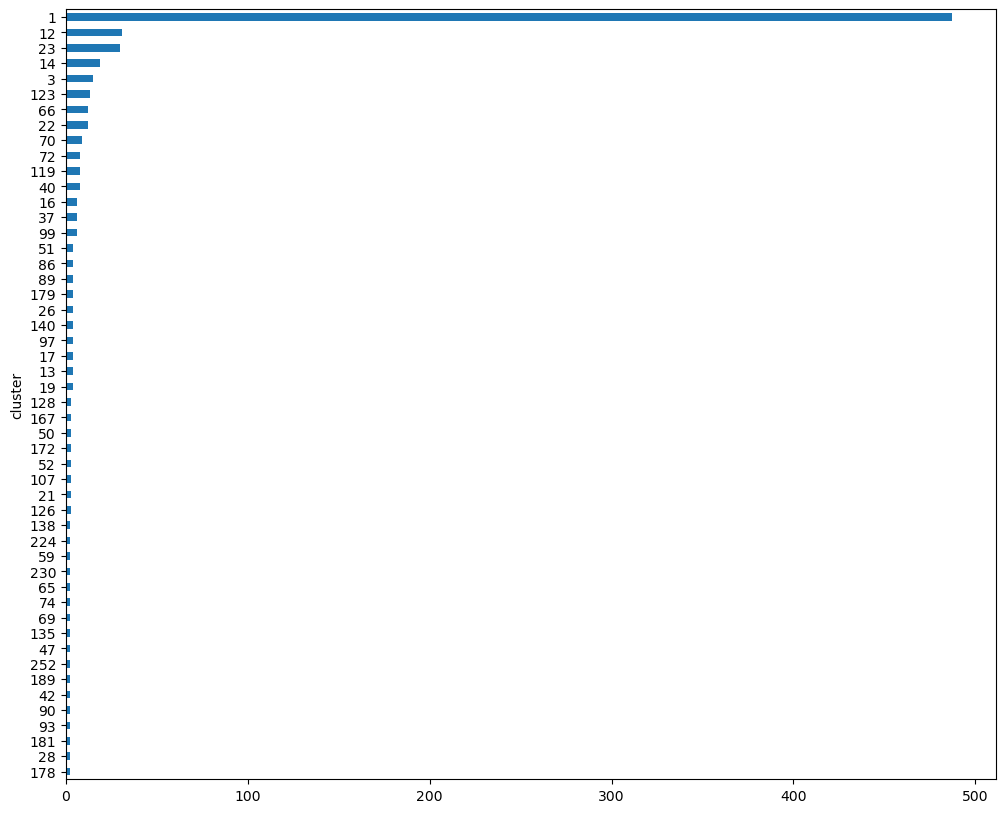

In [67]:
event_df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [68]:
top_clusters = event_df['cluster'].value_counts()[0:20].index.values
top_clusters

array([  1,  12,  23,  14,   3, 123,  66,  22,  70,  72, 119,  40,  16,
        37,  99,  51,  86,  89, 179,  26], dtype=int64)

In [69]:
cluster = top_clusters[0]

event_df[event_df['cluster']==cluster].head(20)['genres']

1     Not provided in source.
4     Not provided in source.
6     Not provided in source.
7     Not provided in source.
10    Not provided in source.
11    Not provided in source.
13    Not provided in source.
17    Not provided in source.
18    Not provided in source.
22    Not provided in source.
23    Not provided in source.
24    Not provided in source.
27    Not provided in source.
28    Not provided in source.
29    Not provided in source.
30    Not provided in source.
32    Not provided in source.
37    Not provided in source.
39    Not provided in source.
40    Not provided in source.
Name: genres, dtype: object

In [70]:
cluster = top_clusters[1]

event_df[event_df['cluster']==cluster].head(20)['genres']

20     Comedy
33     Comedy
68     Comedy
102    Comedy
151    Comedy
192    Comedy
222    Comedy
292    Comedy
306    Comedy
367    Comedy
383    Comedy
404    Comedy
480    Comedy
493    Comedy
507    Comedy
520    Comedy
530    Comedy
550    Comedy
591    Comedy
625    Comedy
Name: genres, dtype: object

In [71]:
cluster = top_clusters[2]

event_df[event_df['cluster']==cluster].head(20)['genres']

45     disco, glam, metal, punk
48     disco, glam, metal, punk
90     disco, glam, metal, punk
140    disco, glam, metal, punk
146    disco, glam, metal, punk
165    disco, glam, metal, punk
193    disco, glam, metal, punk
223    disco, glam, metal, punk
291    disco, glam, metal, punk
319    disco, glam, metal, punk
336    disco, glam, metal, punk
380    disco, glam, metal, punk
418    disco, glam, metal, punk
426    disco, glam, metal, punk
481    disco, glam, metal, punk
491    disco, glam, metal, punk
529    disco, glam, metal, punk
608    disco, glam, metal, punk
661    disco, glam, metal, punk
683    disco, glam, metal, punk
Name: genres, dtype: object

In [72]:
cluster = top_clusters[3]

event_df[event_df['cluster']==cluster].head(20)['genres']

25          Jazz
65     Jazz, R&B
99          Jazz
160         Jazz
164         Jazz
175         Jazz
211         Jazz
213         Jazz
260         Jazz
294         Jazz
430         Jazz
438         Jazz
462         Jazz
477         Jazz
678         Jazz
712         Jazz
754         Jazz
847         Jazz
920         Jazz
Name: genres, dtype: object

In [73]:
cluster = top_clusters[3]

event_df[event_df['cluster']==cluster].head(20)

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url,cluster
25,Lady Sings the Blues - A Tribute to Billie Hol...,Featured performers TBA,"Saturday, April 04, 2026, 7:30 PM",Not provided in source.,Alberta Rose Theatre,"3000 NE Alberta Street, Portland, OR 97211","booking@albertarosetheatre.com, 503.719.6055",The event is the 19th Annual Billie Holiday Tr...,Jazz,https://albertarosetheatre.com/event/lady-sing...,14
65,A Decade in Motion - Philip Mahoney with Speci...,"Philip Mahoney, Jay R","April 11, 2026 7:00pm",$48.50 – $93.50,Patricia Reser Center for the Arts,"12625 SW Crescent St Beaverton, OR 97005",Not provided in source.,Celebrate a milestone evening with Philip Maho...,"Jazz, R&B",https://thereser.org/event/a-decade-in-motion-...,14
99,Huntertones,"Huntertones (Dan White, Jon Lampley, Chris Ott...","April 12, 2026 3:00 pm",$32 – $63,Patricia Reser Center for the Arts,"12625 SW Crescent St, Beaverton, OR 97005",Not provided in source.,Huntertones performs imaginative and fearless ...,Jazz,https://thereser.org/event/huntertones/,14
160,Portland Jazz Festival,Not provided in source.,"Thursday, March 5 - Saturday, March 14 at 12:0...",Not provided in source.,Not provided in source.,"Portland, OR",Not provided in source.,Not provided in source.,Jazz,https://dopdx.com/events/2026/3/5/portland-jaz...,14
164,Medler Mode at Bspace BIAMP Portland Jazz Fest...,"Michelle Medler, Ben Medler, Gordon Lee, Brian...","March 8, 2026, 3:30 pm - 5:30 pm",$25,Burlingame Space,"8423 SW Terwilliger Blvd, PORTLAND, OR, 97219","6200 SW Virginia Ave, Suite 208 Portland, OR 9...",Medler Studios Club Owners Michelle and Ben Me...,Jazz,https://tickettomato.com/event/9907/medler-mod...,14
175,2026 Biamp Portland Jazz Festival,"Shirley Nanette, Mavis Staples, SML, Stumptown...","March 5–14, 2026",Not provided in source.,Not provided in source.,Not provided in source.,Not provided in source.,The 2026 Biamp Portland Jazz Festival features...,Jazz,https://everout.com/portland/events/2026-biamp...,14
211,DELFEAYO MARSALIS & THE UPTOWN JAZZ ORCHESTRA ...,Delfeayo Marsalis & The Uptown Jazz Orchestra,"Saturday, February 21, 2026, Doors: 9:30 pm, S...",$41.69 - $299.19,Jack London Revue,"529 SW 4th Ave, Portland, OR 97204",Not provided in source.,Delfeayo Marsalis leads the Uptown Jazz Orches...,Jazz,https://www.jacklondonrevue.com/tm-event/delfe...,14
213,Lulu Wednesday Jazz,"Dario Lapoma, Patrick Golichnik, Alan Jones & ...","Wednesday, February 25, and then every 7 days,...",Free,Lulu,"726 SE Grand, Portland, Oregon 97214",Not provided in source.,Lulu Wednesday Jazz is a weekly live jazz nigh...,Jazz,https://everout.com/portland/events/lulu-wedne...,14
260,Cyrus Chestnut Trio w/ Alan Jones Trio,"Cyrus Chestnut Trio, Alan Jones Trio","Friday, March 13 at 8:00 pm",$54 - $59,Alberta Rose Theatre,"3000 NE Alberta, Portland, OR 97211",Not provided in source.,"Cyrus Chestnut, an accomplished jazz pianist k...",Jazz,https://everout.com/portland/events/cyrus-ches...,14
294,Jazz Interlude at The Burlingame Space Mt. Hoo...,Jazz Interlude,"Saturday, April 25, 2026, 7:00 pm - 9:00 pm",$20,The Burlingame Space,"8423 SW Terwilliger Blvd, PORTLAND, OR, 97219","Customer Support: 6200 SW Virginia Ave, Suite ...",Jazz Interlude will perform at The Burlingame ...,Jazz,https://tickettomato.com/event/9910/jazz-inter...,14


In [74]:
cluster = top_clusters[4]

event_df[event_df['cluster']==cluster].head(20)['genres']

3      Genres:
130    Genres:
139    Genres:
171    Genres:
251    Genres:
255    Genres:
266    Genres:
301    Genres:
379    Genres:
499    Genres:
590    Genres:
627    Genres:
861    Genres:
863    Genres:
891    Genres:
Name: genres, dtype: object

In [76]:
cluster = top_clusters[5]

event_df[event_df['cluster']==cluster].head(20)['genres']

71     Blues, Blues-Rock
357          Jazz, Blues
421    Jazz, Blues, Soul
539    Jazz, Blues, Soul
593          Jazz, Blues
618    Jazz, Blues, Soul
619    Jazz, Blues, Rock
656    Jazz, Blues, Soul
749    Jazz, Blues, Soul
785          Blues, Rock
806    Jazz, Blues, Soul
987    Jazz, blues, soul
989           Blues-Rock
Name: genres, dtype: object

In [82]:
cluster = top_clusters[5]

event_df[event_df['cluster']==cluster].head(20)

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url,cluster
71,Ronnie Baker Brooks with special guest Mary Fl...,"Ronnie Baker Brooks, Mary Flower","March 02, 2026 6:00 PM",Not provided in source.,Alberta Rose Theatre,"3000 NE Alberta Street, Portland, OR 97211","booking@albertarosetheatre.com, 503.719.6055","Ronnie Baker Brooks, a talented Chicago bluesm...","Blues, Blues-Rock",https://albertarosetheatre.com/event/ronnie-ba...,123
357,Highway 99 All Stars,Highway 99 All Stars,"Tuesday, April 14, 2026 at 7:30 PM",Not provided in source.,Dimitriou's Jazz Alley,Seattle,Not provided in source.,The Highway 99 All Stars will perform at Dimit...,"Jazz, Blues",https://www.knkx.org/ticket-giveaways/2026-03-...,123
421,MEL BROWN B3 ORGAN GROUP,Mel Brown B3 Organ Group,16 April 2026 at 8:00 pm PDT,$26.24 - $206.49,Jack London Revue,"529 SW 4th Ave, Portland, OR 97204",Not provided in source.,"The Mel Brown B3 Organ Group, known for their ...","Jazz, Blues, Soul",https://www.jacklondonrevue.com/tm-event/mel-b...,123
539,MEL BROWN B3 ORGAN GROUP,Mel Brown B3 Organ Group,"Thu February 19, 2026, Doors: 7:00 pm PST, SHO...",$26.24 - $206.49,Jack London Revue,"529 SW 4th Ave, Portland, OR 97204",info@ticketweb.com,"The Mel Brown B3 Organ Group, consisting of Or...","Jazz, Blues, Soul",https://www.jacklondonrevue.com/tm-event/mel-b...,123
593,Biamp PDX Jazz Festival,"ST VINCENT, MAVIS STAPLES, MADELEINE PEYROUX, ...","March 5, 2026 - March 14, 2026, 12:00 AM - 11:...",Not provided in source.,Various venues (Portland Jazz Festival),"Portland, Oregon","503.228.JAZZ (5299), info@pdxjazz.com","The Biamp Portland Jazz Festival is a ten-day,...","Jazz, Blues",https://pdxjazz.org/festival/,123
618,MEL BROWN B3 ORGAN GROUP,Mel Brown B3 Organ Group,"February 5, 2026, 8:00 pm PST",$36.54 - $268.29,Jack London Revue,"529 SW 4th Ave, Portland, OR 97204",Not provided in source.,"The Mel Brown B3 Organ Group, known for its al...","Jazz, Blues, Soul",https://www.jacklondonrevue.com/tm-event/mel-b...,123
619,The Black Mariah Theater / Strange & The Famil...,"The Black Mariah Theater, Strange & The Famili...","February 6, 2026 at 9:00 PM",$15.52,Conor Byrne Pub,Not provided in source.,Not provided in source.,"The Black Mariah Theater, a jazz/blues/rock du...","Jazz, Blues, Rock",https://do206.com/events/2026/2/6/the-black-ma...,123
656,MEL BROWN B3 ORGAN GROUP,Mel Brown B3 Organ Group,"Thursday, April 02, 2026, Doors: 7:00 PM PDT, ...",$26.24 - $206.49,Jack London Revue,"529 SW 4th Ave, Portland, OR 97204",Not provided in source.,"The Mel Brown B3 Organ Group, noted for their ...","Jazz, Blues, Soul",https://www.jacklondonrevue.com/tm-event/mel-b...,123
749,MEL BROWN B3 ORGAN GROUP feat. SAEEDA WRIGHT,"MEL BROWN B3 ORGAN GROUP, SAEEDA WRIGHT","March 12, 2026, Doors: 7:00 pm, Show: 8:00 pm PDT",$28.30 - $213.70,Jack London Revue,"529 SW 4th Ave, Portland, OR 97204",info@ticketweb.com,The event features the Mel Brown B3 Organ Grou...,"Jazz, Blues, Soul",https://www.jacklondonrevue.com/tm-event/mel-b...,123
785,SGT SPLENDOR followed by Sinferno Cabaret - Da...,Sgt. Splendor (featuring Eric McFadden & Kate ...,"February 08, 2026, at 08:30 PM PST",$21.09,Dante's,"350 W Burnside St, Portland, OR, 97209, US","(866) 777-8932, DantesStarTheater@gmail.com","Sgt. Splendor, featuring Eric McFadden and Kat...","Blues, Rock",https://www.danteslive.com/tm-event/sgt-splend...,123


In [77]:
cluster = top_clusters[6]

event_df[event_df['cluster']==cluster].head(20)['genres']

159     Stand-up Comedy
202     Stand-up Comedy
215    Comedy, Stand-up
340     Stand-up Comedy
351     Stand-up comedy
378    Comedy, Stand-up
407    Comedy, Stand-up
469    Comedy, Stand-up
690    Comedy, Stand-up
862     Stand-up Comedy
934    Comedy, Stand-up
947    Comedy, Stand-up
Name: genres, dtype: object

In [78]:
cluster = top_clusters[7]

event_df[event_df['cluster']==cluster].head(20)['genres']

43            Rock
72            Rock
158           Rock
207           Rock
279           Rock
315           Rock
427           Rock
533           Rock
594           Rock
624    R & B, Rock
812           Rock
972           Rock
Name: genres, dtype: object

In [79]:
cluster = top_clusters[8]

event_df[event_df['cluster']==cluster].head(20)['genres']

172                   Hip Hop/Rap
261                   Hip-hop/Rap
348               Hip-Hop/Rap, DJ
494                   Hip-Hop/Rap
498      Jazz, Funk, Hip Hop, Rap
797    Hip-Hop/Rap, R&B/Soul/Funk
865       Electronic, Hip-Hop/Rap
932                       Hip-Hop
969             Hip-Hop/Rap, Jazz
Name: genres, dtype: object

In [80]:
cluster = top_clusters[9]

event_df[event_df['cluster']==cluster].head(20)['genres']

177    Film
210    Film
371    Film
595    Film
609    Film
793    Film
824    Film
909    Film
Name: genres, dtype: object

In [81]:
cluster = top_clusters[10]

event_df[event_df['cluster']==cluster].head(20)['genres']

347    Country/Folk/Bluegrass
453    Country/Folk/Bluegrass
542    Country/Folk/Bluegrass
620    Country/Folk/Bluegrass
723    Country/Folk/Bluegrass
837    Country/Folk/Bluegrass
849    Country/Folk/Bluegrass
872    Country/Folk/Bluegrass
Name: genres, dtype: object

In [83]:
cluster = top_clusters[10]

event_df[event_df['cluster']==cluster].head(20)

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url,cluster
347,Isiah Driessen at Mississippi Pizza Pub & Atla...,Isiah Driessen,"January 10, 2026, 4 pm",Free,Mississippi Pizza Pub & Atlantis Lounge,"3552 N Mississippi, Portland, OR 97227",Not provided in source.,Oregon native Isiah Driessen will perform a fr...,Country/Folk/Bluegrass,https://everout.com/portland/events/isiah-drie...,119
453,Pert Near Sandstone,"Pert Near Sandstone, Dadweed","Saturday, March 7 at 8 pm",$20 - $25,The Showdown,"1195 SE Powell Blvd, Portland, OR 97202",Not provided in source.,Pert Near Sandstone will perform contemporary ...,Country/Folk/Bluegrass,https://everout.com/portland/events/pert-near-...,119
542,Thee Honeybuds,Thee Honeybuds,"Saturday, March 7, 7 pm",$11,Al's Den,"303 SW 12th, Portland, OR 97205",Not provided in source.,Thee Honeybuds will be performing at Al's Den ...,Country/Folk/Bluegrass,https://everout.com/portland/events/thee-honey...,119
620,The Strumbellas: Into Dust Tour,The Strumbellas,"March 9, 2026, 8 pm",$38.08 - $274.88,Aladdin Theater,"3017 SE Milwaukie, Portland, OR 97202",Not provided in source.,The Strumbellas will perform as part of their ...,Country/Folk/Bluegrass,https://everout.com/portland/events/the-strumb...,119
723,Square Dancing with Caller Bex Bee and Boondoggle,Bex Bee and Boondoggle,"Monday, March 9, 7 pm",$12 - $15,The Showdown,"1195 SE Powell Blvd, Portland, OR 97202",Not provided in source.,Join for an evening of square dancing with Cal...,Country/Folk/Bluegrass,https://everout.com/portland/events/square-dan...,119
837,Daniel Donato’s Cosmic Country,Daniel Donato,"Friday, February 6, 2026, 8 pm",$41.70,Revolution Hall,"1300 SE Stark, Portland, OR 97214",Not provided in source.,Daniel Donato's Cosmic Country is a high-energ...,Country/Folk/Bluegrass,https://everout.com/portland/events/daniel-don...,119
849,Ian Munsick,"Ian Munsick, Tyler Nance","February 24, 2026, 8 pm",$47.50 - $159.75,Roseland Theater,"8 NW 6th, Portland, OR 97209",Not provided in source.,Ian Munsick will perform live at the Roseland ...,Country/Folk/Bluegrass,https://everout.com/portland/events/ian-munsic...,119
872,William Elliott Whitmore,William Elliott Whitmore,"January 17, 2026, 9 pm",$26.05,Mississippi Studios,"3939 N Mississippi, Portland, OR 97227",Not provided in source.,"William Elliott Whitmore, known for his soulfu...",Country/Folk/Bluegrass,https://everout.com/portland/events/william-el...,119


# Find a Cluster

Sometimes you will know what you are looking for but not know what cluster it exists in. This will help you find it.

In [84]:
search_term = 'live'

event_df[event_df['genres'].str.contains(search_term, case=False)]

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url,cluster
73,St. Patrick's Day Festival at Wonderlove!,"The Heartbleeders, Joseph Linahon, Cazrep, Sha...","Saturday, March 14 at 1:00 PM to Tuesday, Marc...",Free,Wonderlove,"262 Southeast Main Street, Portland, OR 97214",Not provided in source.,"A multi-day, all ages festival celebrating Iri...","Irish Folk, Live DJ",https://www.eventbrite.com/e/st-patricks-day-f...,33
170,"Pre-Show Performance: New Year, New Sounds","Li Kuang, Julia Hwakyu Lee","February fifteenth, two thousand twenty-six at...",Free Event,Portland Center Stage at The Armory,"128 NW Eleventh Ave, Portland, OR 97209","503-445-3700, boxoffice@pcs.org",A pre-show conversation and performance celebr...,"Live Music, Community Partnerships",https://www.pcs.org/events/pre-show-performanc...,69
353,St. Patrick’s Celebrations,"Ashleigh Flynn & the Riveters, Michelle Alany ...","March 14, 2026 - March 17, 2026, 5:00 PM",Not provided in source.,Kennedy School,Portland,Not provided in source.,St. Patrick's Celebrations featuring live musi...,"Live Music, Entertainment",https://dopdx.com/events/2026/3/14/st-patricks...,122
368,Calysta Cheyenne,Calysta Cheyenne,"Sunday, March 1, 7 pm",$26.10,Al's Den,"303 SW 12th, Portland, OR 97205",Not provided in source.,Calysta Cheyenne will perform live music at Al...,"Live Music, Jazz",https://everout.com/portland/events/calysta-ch...,126
385,BIPOC Affinity Night for The Play That Goes Wrong,Raeamari,"January twenty-four, two thousand twenty-six a...",Free,The Armory,"128 NW Eleventh Ave, Portland, OR 97209","503-445-3700, boxoffice@pcs.org",Join us for a pre-show performance from local ...,Live Music,https://www.pcs.org/events/bipoc-affinity-nigh...,126
419,Pre-Show Performance: Bridging Voices,Bridging Voices,"March 22, 2026 1 p.m. – 2 p.m.",Not provided in source.,Portland Center Stage at The Armory,"128 NW Eleventh Ave, Portland, OR 97209","503-445-3700, boxoffice@pcs.org",A Pre-Show Performance featuring Bridging Voic...,Live Music,https://www.pcs.org/events/pre-show-performanc...,126
705,Working Thru It + BIPOC Affinity Night: MONSTE...,"Ashley Song, Vodou","March 7, 2026 at 4:00 PM – 7:00 PM PST",Not provided in source.,Portland Center Stage,"128 NW Eleventh Ave, Portland, OR 97209","503-445-3700, boxoffice@pcs.org",Join for a special workshop and social event t...,"Live Music, Community Partnerships",https://www.pcs.org/events/monster-fest-workin...,69
850,Diva Drag Brunch: Portland,"ALL STAR cast of Drag, Burlesque, Acrobatics, ...",25 January 2026 at 11:00 AM,$20.00,Swan Dive,"727 SE Grand Ave, Portland, OR 97214",Not provided in source.,Diva Drag Brunch is a popular drag brunch even...,"Drag, Burlesque, Acrobatics, Live Singing",https://www.merctickets.com/events/176114104/d...,239


# Graph Analysis

We could do a bipartite network, but I don't want to spend a lot of time on this right now. I want to first just show that this can be converted into a graph. I will create a simple bipartite graph.

In [107]:
edge_df = event_df[['performers', 'genres']]


edge_df = edge_df[edge_df['performers'].str.contains('not provided', case=False)==False]
edge_df = edge_df[edge_df['genres'].str.contains('not provided', case=False)==False]
edge_df['performers'] = edge_df['performers'].apply(lambda s: s.split(', '))

edge_df = edge_df.explode('performers')

edge_df.head()

,performers,genres
2,Virtuoso pianists from the University of Orego...,Modern Classical
9,The Messthetics,"Jazz, Experimental"
9,James Brandon Lewis,"Jazz, Experimental"
12,Chandler Trey Johnson & Milo Gonzalez,Psychedelic
14,Alton Miller,House Music


In [108]:
G = nx.from_pandas_edgelist(edge_df, source='performers', target='genres')
print(G)

Graph with 1075 nodes and 880 edges


In [110]:
sorted(G.nodes)[0:100]

['',
 '"Drawing on the Walls" is a performance featuring WindSync and BodyVox at the Portland Community College\'s Performing Arts Center.',
 '80s alternative music',
 '@lotsofhands',
 'A Lot Like Birds',
 'A Nordic Musical Banquet featuring Grieg’s Piano Concerto performed by Joyce Yang, along with Sibelius’ The Swan of Tuonela and Stenhammar’s Symphony No. 2, conducted by David Danzmayr.',
 'ALAN JONES TRIO',
 'ALL STAR cast and the best performers that Portland (and beyond) has to offer.',
 'ALL STAR cast of Drag',
 'ALL STAR cast of drag performers',
 'Aaron Monte',
 'Acrobatics',
 'Adam Beam',
 'Adam DeAscentis',
 'Adam Fleming',
 'Adam Friedland',
 'Adam Harris',
 'Adam Pasi',
 'Adam Pasi (Host)',
 'Adam Ray',
 'Aerial, Dance',
 'Affinity Trio',
 'Afrobeat, Juju',
 'Akaash Singh',
 'Alaina Fidanzo',
 'Alan Jones & Pabalo',
 'Alan Jones Trio',
 'Alex Skolnick',
 'Alexandr Misko',
 'Alexis Scheer',
 'Alison Wonderland',
 'All Hype',
 "All Star cast featuring Portland's best perform

# Save to File for Downstream Work

In [101]:
event_df.head(1)

,title,performers,event_dates,price,venue,location,contact_information,description,genres,source_url,cluster
0,Conexión Latina,Not provided in source.,"March 27, 2026 5:30 PM - 8:00 PM",Not provided in source.,Not provided in source.,Not provided in source.,Name: Christian Arroyo,,,,0


In [102]:
outfile = 'data/gsv3/gsv3_searches/local_events.csv'

event_df.to_csv(outfile, header=True, index=False)